# Assignment 3: Product Recommendation

In this assignment, we build a simple rule-based product recommendation feature.

**Rules:**
1. If a user's rating is >= 4, we recommend the same brand.
2. If a user's rating is < 4, we recommend a different brand (e.g. switch from Apple to Samsung, or vice versa).

In [1]:
import json

with open('assignment3_data.json', 'r') as f:
    recomm_data = json.load(f)


## Building the Recommendation Engine

We will apply the rules defined above to suggest a new brand for the customer.

In [2]:
def get_recommendation(data):
    recommendation = []
    
    for user in data:
        curr_recomm = {
            'customer_name': user.get('customer_name'),
            'original_brand': user.get('brand'),
            'rating': user.get('rating'),
        }
        
        # Apply Rules
        if float(user['rating']) >= 4:
            curr_recomm['recommended_brand'] = user.get('brand')
        else:
            curr_recomm['recommended_brand'] = 'Samsung' if user.get('brand') == 'Apple' else 'Apple'
            
        recommendation.append(curr_recomm)
        
    return recommendation

output = get_recommendation(recomm_data)
for item in output:
    print(item)

{'customer_name': 'Alice', 'original_brand': 'Apple', 'rating': 5, 'recommended_brand': 'Apple'}
{'customer_name': 'Bob', 'original_brand': 'Apple', 'rating': 4, 'recommended_brand': 'Apple'}
{'customer_name': 'Charlie', 'original_brand': 'Samsung', 'rating': 1, 'recommended_brand': 'Apple'}


## 3. Visualizing Recommendations

Let's visualize how many users were recommended their original brand vs a new brand.

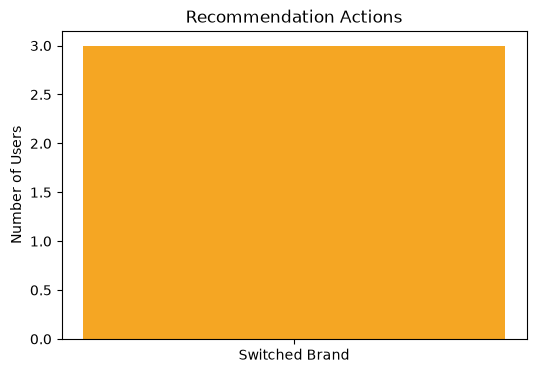

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Analyze the recommendations
actions = []
for user in output:
    if user.get('brand') == user.get('recommended_brand'):
        actions.append('Kept Brand')
    else:
        actions.append('Switched Brand')

action_counts = Counter(actions)

plt.figure(figsize=(6, 4))
plt.bar(action_counts.keys(), action_counts.values(), color=['#F5A623', '#4A90E2'])
plt.title('Recommendation Actions')
plt.ylabel('Number of Users')
plt.show()
